# Pilot ECIS Data Analysis
This notebook loads pilot ECIS data, filters to a single frequency (500 Hz), normalizes the signal to baseline, compares technical replicates, and extracts simple quantitative features from the ECIS response.

In [1]:
import os
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

## 1. Locate and Load the Pilot ECIS File
First, check the current working directory and confirm where the ECIS CSV files are stored.

In [2]:
print("Current working directory:")
print(os.getcwd())

print("\nFiles in current directory:")
print(os.listdir())

Current working directory:
/Users/danyaleyva/Desktop/Project ECIS/notebooks

Files in current directory:
['ECIS_analysis.ipynb', '.ipynb_checkpoints']


## 2. Define File Paths
Set the file paths for the pilot ECIS replicate files.  
Update the folder path below if your CSV files are stored somewhere else.

In [3]:
# Change this path if your files are in a different folder
base_path = Path("../data/ecis_simulated_pilot (1)")

file_r1 = base_path / "pilot_sim_001_C1_R1.csv"
file_r2 = base_path / "pilot_sim_001_C1_R2.csv"
file_r3 = base_path / "pilot_sim_001_C1_R3.csv"

print(file_r1)
print(file_r2)
print(file_r3)

../data/ecis_simulated_pilot (1)/pilot_sim_001_C1_R1.csv
../data/ecis_simulated_pilot (1)/pilot_sim_001_C1_R2.csv
../data/ecis_simulated_pilot (1)/pilot_sim_001_C1_R3.csv


## 3. Load One Pilot ECIS File
Load one replicate first to inspect the dataset structure.

In [4]:
df = pd.read_csv(file_r1)
df.head()

,Time_min,Frequency_Hz,Impedance_Magnitude
0,0,500,862.929851
1,5,500,862.252284
2,10,500,873.224971
3,15,500,874.821405
4,20,500,865.888778


## 4. Plot the Raw ECIS Signal
Plot the raw impedance magnitude over time before filtering by frequency.

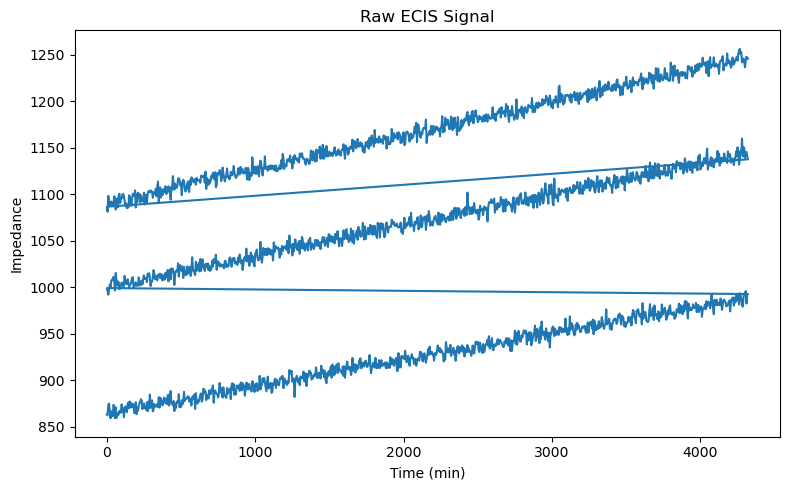

In [5]:
plt.figure(figsize=(8, 5))
plt.plot(df["Time_min"], df["Impedance_Magnitude"])

plt.xlabel("Time (min)")
plt.ylabel("Impedance")
plt.title("Raw ECIS Signal")
plt.tight_layout()
plt.show()

## 5. Filter to 500 Hz
ECIS data contain multiple frequencies. For this initial pilot analysis, we focus on the 500 Hz signal.

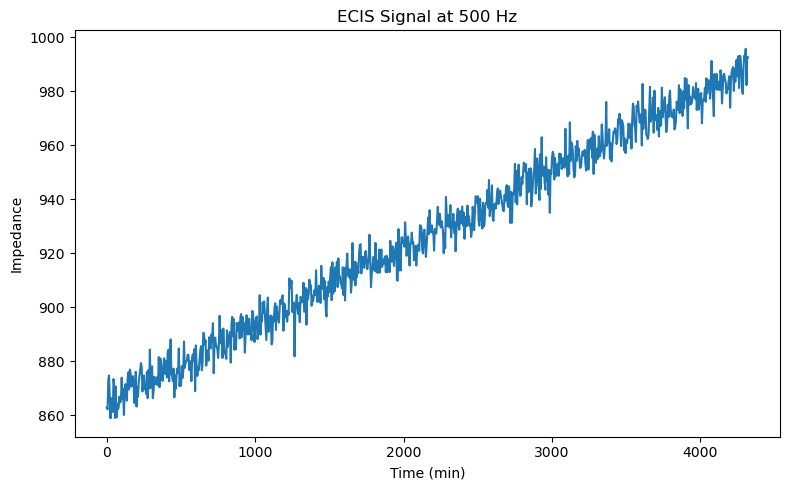

In [6]:
df_500 = df[df["Frequency_Hz"] == 500].copy()

plt.figure(figsize=(8, 5))
plt.plot(df_500["Time_min"], df_500["Impedance_Magnitude"])

plt.xlabel("Time (min)")
plt.ylabel("Impedance")
plt.title("ECIS Signal at 500 Hz")
plt.tight_layout()
plt.show()

## 6. Normalize the ECIS Signal to Baseline
Normalize the 500 Hz impedance signal using the first recorded value as the baseline so the curve begins near 1.0.

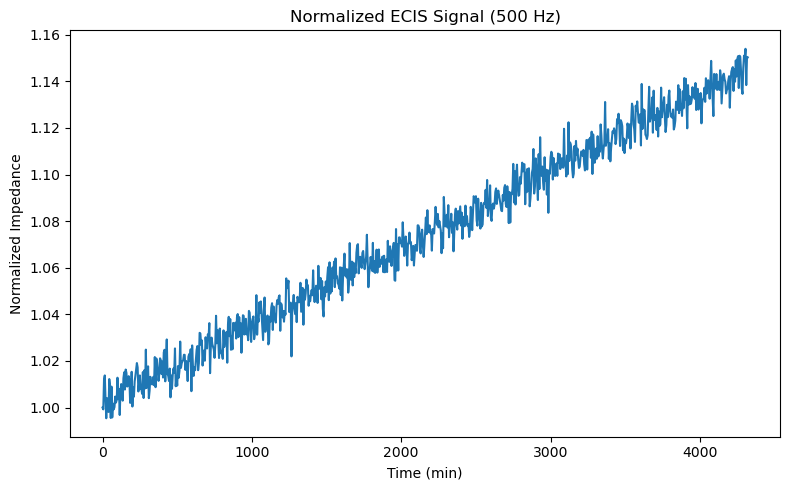

In [7]:
baseline = df_500["Impedance_Magnitude"].iloc[0]
df_500["Normalized"] = df_500["Impedance_Magnitude"] / baseline

plt.figure(figsize=(8, 5))
plt.plot(df_500["Time_min"], df_500["Normalized"])

plt.xlabel("Time (min)")
plt.ylabel("Normalized Impedance")
plt.title("Normalized ECIS Signal (500 Hz)")
plt.tight_layout()
plt.show()

## 7. Compare Technical Replicates
Load replicates R1, R2, and R3, normalize each trace, and compare them on the same plot.

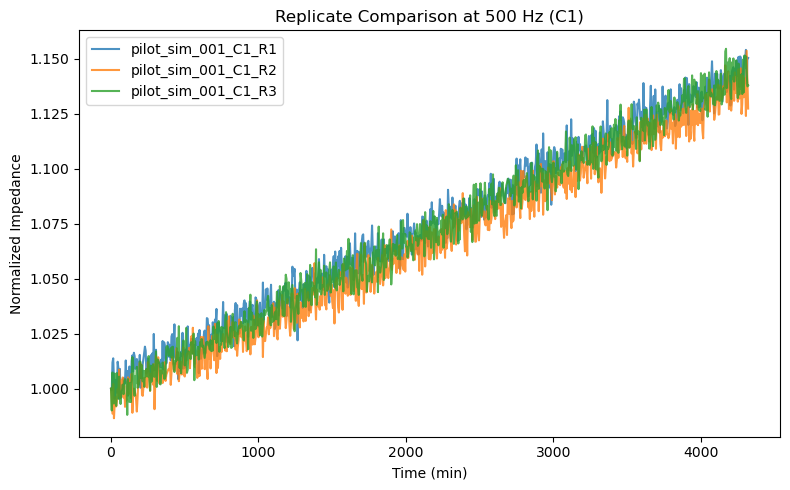

In [8]:
files = [file_r1, file_r2, file_r3]

plt.figure(figsize=(8, 5))

for file in files:
    df_rep = pd.read_csv(file)
    df_rep_500 = df_rep[df_rep["Frequency_Hz"] == 500].copy()

    baseline = df_rep_500["Impedance_Magnitude"].iloc[0]
    df_rep_500["Normalized"] = df_rep_500["Impedance_Magnitude"] / baseline

    plt.plot(df_rep_500["Time_min"], df_rep_500["Normalized"], alpha=0.8, label=file.stem)

plt.xlabel("Time (min)")
plt.ylabel("Normalized Impedance")
plt.title("Replicate Comparison at 500 Hz (C1)")
plt.legend()
plt.tight_layout()
plt.show()

## 8. Compute Mean and Standard Deviation Across Replicates
Calculate the average normalized ECIS response and variability across the three technical replicates.

In [9]:
replicates = []

for file in files:
    df_rep = pd.read_csv(file)
    df_rep_500 = df_rep[df_rep["Frequency_Hz"] == 500].copy()

    baseline = df_rep_500["Impedance_Magnitude"].iloc[0]
    norm = df_rep_500["Impedance_Magnitude"] / baseline

    replicates.append(norm.values)

replicates = np.array(replicates)

mean_signal = replicates.mean(axis=0)
std_signal = replicates.std(axis=0)

time = df_rep_500["Time_min"].values

## 9. Plot the Mean ECIS Response with Variability
Visualize the mean normalized impedance curve with a shaded band representing plus/minus one standard deviation.

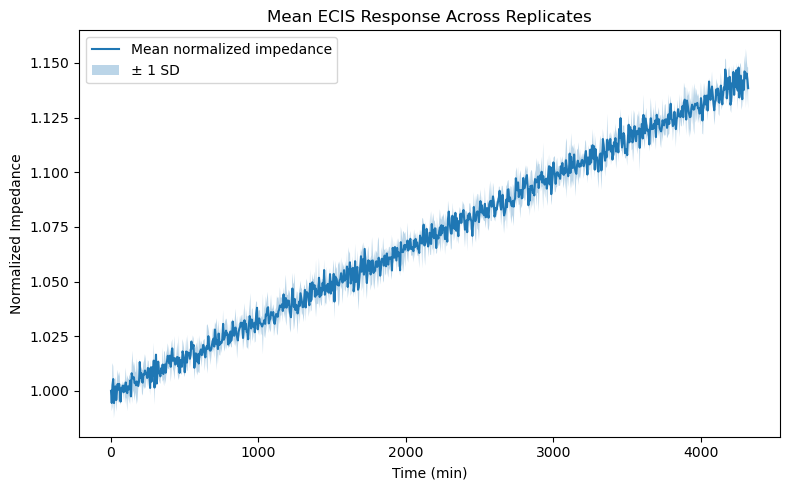

In [10]:
plt.figure(figsize=(8, 5))
plt.plot(time, mean_signal, label="Mean normalized impedance")
plt.fill_between(
    time,
    mean_signal - std_signal,
    mean_signal + std_signal,
    alpha=0.3,
    label="± 1 SD"
)

plt.xlabel("Time (min)")
plt.ylabel("Normalized Impedance")
plt.title("Mean ECIS Response Across Replicates")
plt.legend()
plt.tight_layout()
plt.show()

## 10. Assign the Experimental Condition
Label this pilot dataset as the control condition for organized feature tracking.

In [11]:
condition_name = "Control"

## 11. Extract Simple Quantitative Features
Extract basic ECIS features from the normalized signal:
- maximum normalized impedance
- time of maximum impedance
- approximate growth slope

In [12]:
max_impedance = df_500["Normalized"].max()
time_of_max = df_500.loc[df_500["Normalized"].idxmax(), "Time_min"]

slope = (
    df_500["Normalized"].iloc[-1] - df_500["Normalized"].iloc[0]
) / (
    df_500["Time_min"].iloc[-1] - df_500["Time_min"].iloc[0]
)

print("Maximum normalized impedance:", max_impedance)
print("Time of maximum impedance:", time_of_max)
print("Approximate growth slope:", slope)

Maximum normalized impedance: 1.1539446700084526
Time of maximum impedance: 4305
Approximate growth slope: 3.4787186073399857e-05


## 12. Store Extracted Features in a Results Table
Organize the extracted values into a small summary table for later comparison across conditions.

In [13]:
results = pd.DataFrame({
    "Condition": [condition_name],
    "Max_Impedance": [max_impedance],
    "Time_of_Max": [time_of_max],
    "Slope": [slope]
})

results

,Condition,Max_Impedance,Time_of_Max,Slope
0,Control,1.153945,4305,0.000035


## 13. Plot a Preliminary Feature Summary
Create a simple summary plot for the current condition. This will be more useful once additional conditions are added.

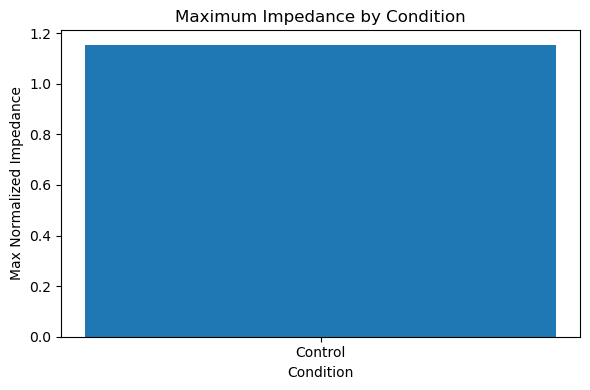

In [14]:
plt.figure(figsize=(6, 4))
plt.bar(results["Condition"], results["Max_Impedance"])

plt.xlabel("Condition")
plt.ylabel("Max Normalized Impedance")
plt.title("Maximum Impedance by Condition")
plt.tight_layout()
plt.show()

## 14. Interpretation
The pilot ECIS datasets were successfully loaded and processed in Python using JupyterLab. The signals were filtered to a single frequency of 500 Hz and normalized to baseline to enable direct comparison across wells.

Replicate comparison across R1–R3 showed relatively consistent impedance trajectories with low variability, suggesting stable signal acquisition during the pilot experiment.

Simple quantitative features, including maximum normalized impedance, time to maximum response, and approximate slope, were extracted successfully. These results provide an initial baseline for later comparisons across experimental conditions.

At this stage, the preprocessing and pilot replicate, check pipeline is functioning correctly.

## 15. Next Step
The next stage of analysis is to expand beyond a single pilot condition and compare multiple ECIS conditions using the same preprocessing pipeline. This will include analyzing additional wells, summarizing features across conditions, and later extending the analysis to richer multi-frequency and model-based ECIS interpretation.

## 16. Load Metadata for All Pilot Wells
This section loads the pilot metadata so all wells can be analyzed together instead of only one control condition.

In [15]:
metadata = pd.read_csv("../data/ecis_simulated_pilot (1)/ecis_metadata.csv")
metadata

,run_id,well_id,file_path,dose_A,dose_B,lag_hr,order,time_unit
0,pilot_sim_001,C1_R1,pilot_sim_001_C1_R1.csv,0,0,0,A_then_B,min
1,pilot_sim_001,C1_R2,pilot_sim_001_C1_R2.csv,0,0,0,A_then_B,min
2,pilot_sim_001,C1_R3,pilot_sim_001_C1_R3.csv,0,0,0,A_then_B,min
3,pilot_sim_001,C2_R1,pilot_sim_001_C2_R1.csv,10,0,0,A_then_B,min
4,pilot_sim_001,C2_R2,pilot_sim_001_C2_R2.csv,10,0,0,A_then_B,min
5,pilot_sim_001,C2_R3,pilot_sim_001_C2_R3.csv,10,0,0,A_then_B,min
6,pilot_sim_001,C3_R1,pilot_sim_001_C3_R1.csv,0,10,0,A_then_B,min
7,pilot_sim_001,C3_R2,pilot_sim_001_C3_R2.csv,0,10,0,A_then_B,min
8,pilot_sim_001,C3_R3,pilot_sim_001_C3_R3.csv,0,10,0,A_then_B,min
9,pilot_sim_001,C4_R1,pilot_sim_001_C4_R1.csv,10,10,0,A_then_B,min


## 17. Create Condition Labels
Create a readable condition label from dose, lag, and order so the wells can be grouped more clearly.

In [16]:
def make_condition_label(row):
    if row["dose_A"] == 0 and row["dose_B"] == 0:
        return "Control"
    elif row["dose_A"] > 0 and row["dose_B"] == 0:
        return "A only"
    elif row["dose_A"] == 0 and row["dose_B"] > 0:
        return "B only"
    elif row["dose_A"] > 0 and row["dose_B"] > 0 and row["lag_hr"] == 0:
        return "A + B (same time)"
    elif row["dose_A"] > 0 and row["dose_B"] > 0 and row["lag_hr"] > 0 and row["order"] == "A_then_B":
        return f"A then B ({row['lag_hr']} hr lag)"
    elif row["dose_A"] > 0 and row["dose_B"] > 0 and row["lag_hr"] > 0 and row["order"] == "B_then_A":
        return f"B then A ({row['lag_hr']} hr lag)"
    else:
        return "Other"

metadata["Condition"] = metadata.apply(make_condition_label, axis=1)

metadata[["well_id", "dose_A", "dose_B", "lag_hr", "order", "Condition"]]

,well_id,dose_A,dose_B,lag_hr,order,Condition
0,C1_R1,0,0,0,A_then_B,Control
1,C1_R2,0,0,0,A_then_B,Control
2,C1_R3,0,0,0,A_then_B,Control
3,C2_R1,10,0,0,A_then_B,A only
4,C2_R2,10,0,0,A_then_B,A only
5,C2_R3,10,0,0,A_then_B,A only
6,C3_R1,0,10,0,A_then_B,B only
7,C3_R2,0,10,0,A_then_B,B only
8,C3_R3,0,10,0,A_then_B,B only
9,C4_R1,10,10,0,A_then_B,A + B (same time)


## 18. Extract Features for Every Well at 500 Hz
For each well, load the CSV, filter to 500 Hz, normalize to baseline, and extract simple ECIS features.

In [17]:
base_dir = "../data/ecis_simulated_pilot (1)"

all_results = []

for _, row in metadata.iterrows():
    file_path = f"{base_dir}/{row['file_path']}"
    df_well = pd.read_csv(file_path)

    # keep only 500 Hz for now
    df_500 = df_well[df_well["Frequency_Hz"] == 500].copy()

    # normalize to baseline
    baseline = df_500["Impedance_Magnitude"].iloc[0]
    df_500["Normalized"] = df_500["Impedance_Magnitude"] / baseline

    # simple features
    max_impedance = df_500["Normalized"].max()
    time_of_max = df_500.loc[df_500["Normalized"].idxmax(), "Time_min"]
    final_impedance = df_500["Normalized"].iloc[-1]

    slope = (
        df_500["Normalized"].iloc[-1] - df_500["Normalized"].iloc[0]
    ) / (
        df_500["Time_min"].iloc[-1] - df_500["Time_min"].iloc[0]
    )

    all_results.append({
        "well_id": row["well_id"],
        "Condition": row["Condition"],
        "dose_A": row["dose_A"],
        "dose_B": row["dose_B"],
        "lag_hr": row["lag_hr"],
        "order": row["order"],
        "Max_Impedance": max_impedance,
        "Time_of_Max": time_of_max,
        "Final_Impedance": final_impedance,
        "Slope": slope
    })

results_all = pd.DataFrame(all_results)
results_all

,well_id,Condition,dose_A,dose_B,lag_hr,order,Max_Impedance,Time_of_Max,Final_Impedance,Slope
0,C1_R1,Control,0,0,0,A_then_B,1.153945,4305,1.150281,0.000035
1,C1_R2,Control,0,0,0,A_then_B,1.153550,4310,1.127284,0.000029
2,C1_R3,Control,0,0,0,A_then_B,1.154438,4170,1.137824,0.000032
3,C2_R1,A only,10,0,0,A_then_B,1.150593,4300,1.145695,0.000034
4,C2_R2,A only,10,0,0,A_then_B,1.145838,4300,1.130287,0.000030
5,C2_R3,A only,10,0,0,A_then_B,1.145879,4270,1.132684,0.000031
6,C3_R1,B only,0,10,0,A_then_B,1.138689,4315,1.123662,0.000029
7,C3_R2,B only,0,10,0,A_then_B,1.134700,4165,1.133056,0.000031
8,C3_R3,B only,0,10,0,A_then_B,1.149131,4270,1.115706,0.000027
9,C4_R1,A + B (same time),10,10,0,A_then_B,1.148301,4305,1.132189,0.000031


## 19. Summarize Features by Condition
Group technical replicates together and calculate the mean and standard deviation for each condition.

In [18]:
condition_summary = (
    results_all
    .groupby("Condition")
    .agg(
        Mean_Max_Impedance=("Max_Impedance", "mean"),
        SD_Max_Impedance=("Max_Impedance", "std"),
        Mean_Time_of_Max=("Time_of_Max", "mean"),
        SD_Time_of_Max=("Time_of_Max", "std"),
        Mean_Final_Impedance=("Final_Impedance", "mean"),
        SD_Final_Impedance=("Final_Impedance", "std"),
        Mean_Slope=("Slope", "mean"),
        SD_Slope=("Slope", "std")
    )
    .reset_index()
)

condition_summary

,Condition,Mean_Max_Impedance,SD_Max_Impedance,Mean_Time_of_Max,SD_Time_of_Max,Mean_Final_Impedance,SD_Final_Impedance,Mean_Slope,SD_Slope
0,A + B (same time),1.139002,0.008053,4253.333333,50.083264,1.128749,0.003117,0.000030,7.214205e-07
1,A only,1.147437,0.002733,4290.000000,17.320508,1.136222,0.008291,0.000032,1.919230e-06
2,A then B (6 hr lag),1.125745,0.006603,4165.000000,21.794495,1.117496,0.009278,0.000027,2.147777e-06
3,B only,1.140840,0.007452,4250.000000,76.974022,1.124141,0.008685,0.000029,2.010385e-06
4,B then A (6 hr lag),1.127131,0.006490,4253.333333,98.149546,1.114934,0.004570,0.000027,1.057958e-06
5,Control,1.153978,0.000445,4261.666667,79.425017,1.138463,0.011512,0.000032,2.664749e-06


## 20. Plot Maximum Normalized Impedance by Condition
This compares the peak normalized impedance across all pilot conditions.

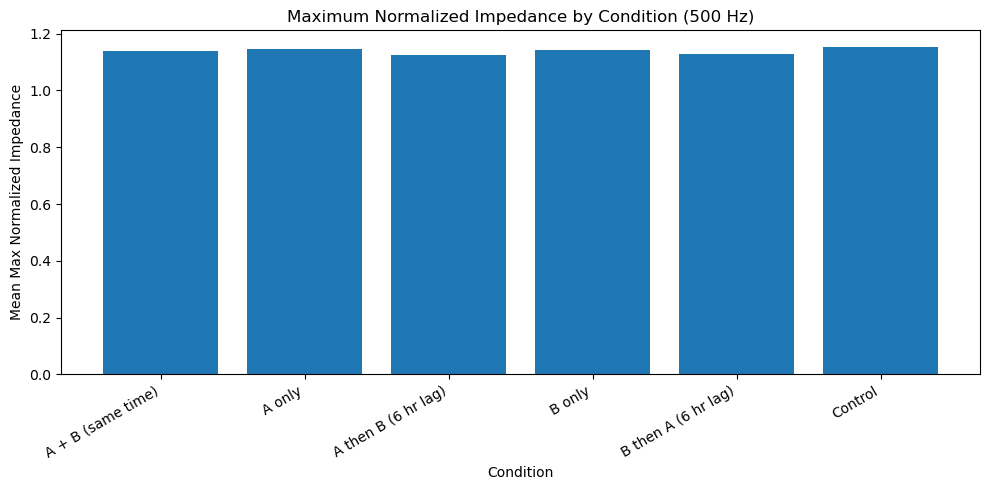

In [19]:
plt.figure(figsize=(10, 5))
plt.bar(condition_summary["Condition"], condition_summary["Mean_Max_Impedance"])

plt.xlabel("Condition")
plt.ylabel("Mean Max Normalized Impedance")
plt.title("Maximum Normalized Impedance by Condition (500 Hz)")
plt.xticks(rotation=30, ha="right")
plt.tight_layout()
plt.show()

## 21. Plot Time of Maximum Response by Condition
This shows when each condition reaches its maximum normalized impedance.

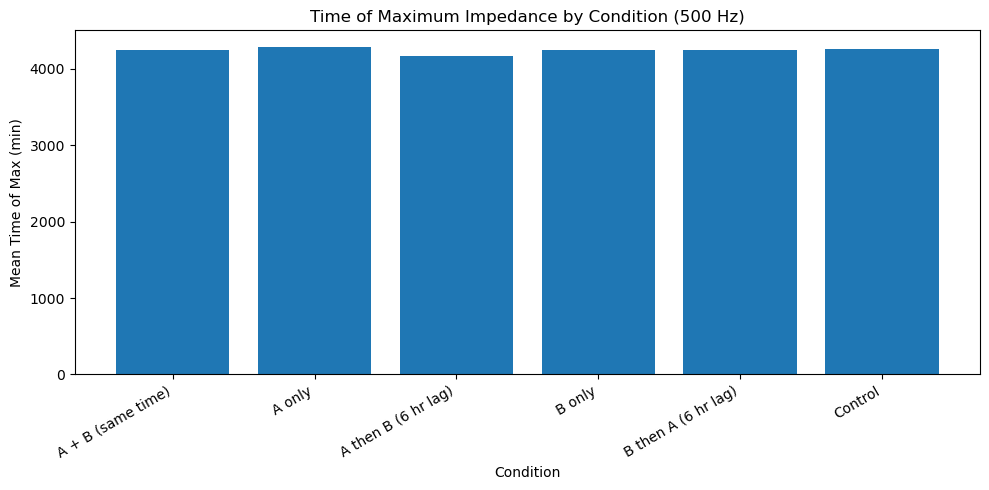

In [20]:
plt.figure(figsize=(10, 5))
plt.bar(condition_summary["Condition"], condition_summary["Mean_Time_of_Max"])

plt.xlabel("Condition")
plt.ylabel("Mean Time of Max (min)")
plt.title("Time of Maximum Impedance by Condition (500 Hz)")
plt.xticks(rotation=30, ha="right")
plt.tight_layout()
plt.show()

## 22. Plot Growth Slope by Condition
This compares the approximate overall growth trend across conditions.

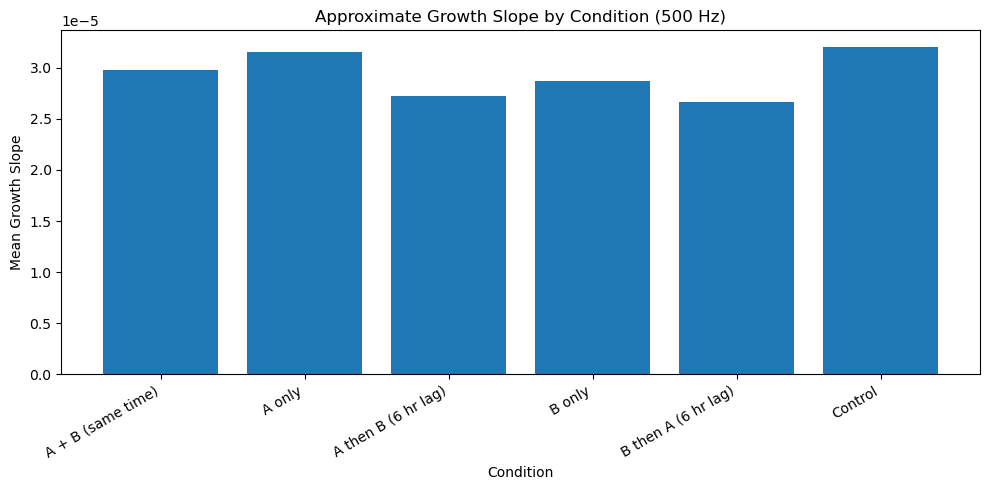

In [21]:
plt.figure(figsize=(10, 5))
plt.bar(condition_summary["Condition"], condition_summary["Mean_Slope"])

plt.xlabel("Condition")
plt.ylabel("Mean Growth Slope")
plt.title("Approximate Growth Slope by Condition (500 Hz)")
plt.xticks(rotation=30, ha="right")
plt.tight_layout()
plt.show()

## 23. Overlay Mean Normalized Curves by Condition
Plot the average normalized 500 Hz curve for each condition to compare full time-course behavior.

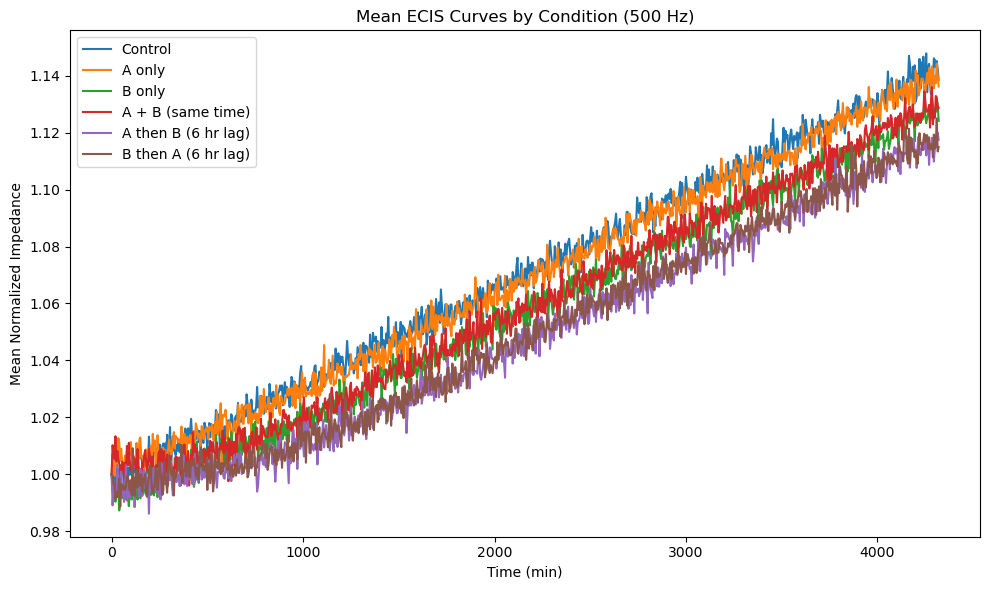

In [22]:
plt.figure(figsize=(10, 6))

for condition in metadata["Condition"].unique():
    condition_wells = metadata[metadata["Condition"] == condition]["file_path"]

    curves = []

    for file_name in condition_wells:
        df_well = pd.read_csv(f"{base_dir}/{file_name}")
        df_500 = df_well[df_well["Frequency_Hz"] == 500].copy()

        baseline = df_500["Impedance_Magnitude"].iloc[0]
        df_500["Normalized"] = df_500["Impedance_Magnitude"] / baseline

        curves.append(df_500["Normalized"].values)

    curves = np.array(curves)
    mean_curve = curves.mean(axis=0)
    time = df_500["Time_min"].values

    plt.plot(time, mean_curve, label=condition)

plt.xlabel("Time (min)")
plt.ylabel("Mean Normalized Impedance")
plt.title("Mean ECIS Curves by Condition (500 Hz)")
plt.legend()
plt.tight_layout()
plt.show()

## 24. Interpretation
This section summarizes the first condition-level comparison across the pilot ECIS wells.

In [23]:
condition_summary

,Condition,Mean_Max_Impedance,SD_Max_Impedance,Mean_Time_of_Max,SD_Time_of_Max,Mean_Final_Impedance,SD_Final_Impedance,Mean_Slope,SD_Slope
0,A + B (same time),1.139002,0.008053,4253.333333,50.083264,1.128749,0.003117,0.000030,7.214205e-07
1,A only,1.147437,0.002733,4290.000000,17.320508,1.136222,0.008291,0.000032,1.919230e-06
2,A then B (6 hr lag),1.125745,0.006603,4165.000000,21.794495,1.117496,0.009278,0.000027,2.147777e-06
3,B only,1.140840,0.007452,4250.000000,76.974022,1.124141,0.008685,0.000029,2.010385e-06
4,B then A (6 hr lag),1.127131,0.006490,4253.333333,98.149546,1.114934,0.004570,0.000027,1.057958e-06
5,Control,1.153978,0.000445,4261.666667,79.425017,1.138463,0.011512,0.000032,2.664749e-06


At this stage, the analysis has moved beyond a single control-style well and now compares all pilot conditions at 500 Hz.

The extracted feature table includes maximum normalized impedance, time of maximum response, final normalized impedance, and approximate growth slope for every well. These values were then summarized across technical replicates for each condition.

This provides the first condition-level comparison framework for evaluating the effects of dose, lag, and order in the pilot ECIS dataset.

The next step will be to repeat this comparison at additional frequencies and determine whether the same trends remain consistent across the multifrequency ECIS signal.

## 25.Create a Resuable Function for Conditin Comaprison at Any Frequency 
This function repeats the same featrues extaction and condition-summary workflow for a selected ECIS frequency. 

In [26]:
def analyze_frequency(metadata, base_dir, frequency_hz):
    all_results = []

    for _, row in metadata.iterrows():
        file_path = f"{base_dir}/{row['file_path']}"
        df_well = pd.read_csv(file_path)

        # filter to chosen frequency
        df_freq = df_well[df_well["Frequency_Hz"] == frequency_hz].copy()

        # normalize to baseline
        baseline = df_freq["Impedance_Magnitude"].iloc[0]
        df_freq["Normalized"] = df_freq["Impedance_Magnitude"] / baseline

        # extract features
        max_impedance = df_freq["Normalized"].max()
        time_of_max = df_freq.loc[df_freq["Normalized"].idxmax(), "Time_min"]
        final_impedance = df_freq["Normalized"].iloc[-1]

        slope = (
            df_freq["Normalized"].iloc[-1] - df_freq["Normalized"].iloc[0]
        ) / (
            df_freq["Time_min"].iloc[-1] - df_freq["Time_min"].iloc[0]
        )

        all_results.append({
            "well_id": row["well_id"],
            "Condition": row["Condition"],
            "dose_A": row["dose_A"],
            "dose_B": row["dose_B"],
            "lag_hr": row["lag_hr"],
            "order": row["order"],
            "Frequency_Hz": frequency_hz,
            "Max_Impedance": max_impedance,
            "Time_of_Max": time_of_max,
            "Final_Impedance": final_impedance,
            "Slope": slope
        })

    results_all = pd.DataFrame(all_results)

    condition_summary = (
        results_all
        .groupby("Condition")
        .agg(
            Mean_Max_Impedance=("Max_Impedance", "mean"),
            SD_Max_Impedance=("Max_Impedance", "std"),
            Mean_Time_of_Max=("Time_of_Max", "mean"),
            SD_Time_of_Max=("Time_of_Max", "std"),
            Mean_Final_Impedance=("Final_Impedance", "mean"),
            SD_Final_Impedance=("Final_Impedance", "std"),
            Mean_Slope=("Slope", "mean"),
            SD_Slope=("Slope", "std")
        )
        .reset_index()
    )

    return results_all, condition_summary

## 26. Run the Same Analysis at 4000 Hz and 16000 Hz
This extends the condition-comparison workflow to additonal ECIS frequencies.

In [27]:
results_4000, summary_4000 = analyze_frequency(metadata, base_dir, 4000)
results_16000, summary_16000 = analyze_frequency(metadata, base_dir, 16000)

## 27. View Conditon Summaried for 4000 Hz and 16000 Hz 

In [28]:
print("4000 Hz summary")
display(summary_4000)

print("16000 Hz summary")
display(summary_16000)

4000 Hz summary


,Condition,Mean_Max_Impedance,SD_Max_Impedance,Mean_Time_of_Max,SD_Time_of_Max,Mean_Final_Impedance,SD_Final_Impedance,Mean_Slope,SD_Slope
0,A + B (same time),1.136032,0.002672,4158.333333,50.083264,1.117673,0.003428,0.000027,7.934690e-07
1,A only,1.139640,0.003414,4208.333333,80.983537,1.125781,0.005611,0.000029,1.298832e-06
2,A then B (6 hr lag),1.136011,0.004126,4260.000000,30.413813,1.129465,0.010059,0.000030,2.328570e-06
3,B only,1.140456,0.006522,4290.000000,36.055513,1.136654,0.008823,0.000032,2.042445e-06
4,B then A (6 hr lag),1.134243,0.000609,4311.666667,10.408330,1.131466,0.003505,0.000030,8.113709e-07
5,Control,1.151932,0.008380,4201.666667,75.221894,1.141269,0.002304,0.000033,5.333639e-07


16000 Hz summary


,Condition,Mean_Max_Impedance,SD_Max_Impedance,Mean_Time_of_Max,SD_Time_of_Max,Mean_Final_Impedance,SD_Final_Impedance,Mean_Slope,SD_Slope
0,A + B (same time),1.134170,0.001885,4261.666667,41.932485,1.126236,0.002010,0.000029,4.653892e-07
1,A only,1.140061,0.005302,4298.333333,16.072751,1.132530,0.011078,0.000031,2.564309e-06
2,A then B (6 hr lag),1.133882,0.004131,4271.666667,48.045118,1.121470,0.010122,0.000028,2.343159e-06
3,B only,1.142923,0.000489,4280.000000,36.055513,1.136044,0.001136,0.000031,2.629554e-07
4,B then A (6 hr lag),1.130702,0.006191,4286.666667,25.166115,1.124812,0.002555,0.000029,5.915410e-07
5,Control,1.153428,0.002837,4280.000000,15.000000,1.144477,0.005210,0.000033,1.206055e-06


## 28. Plot Maximum Normalized Impedence at 4000 Hz 

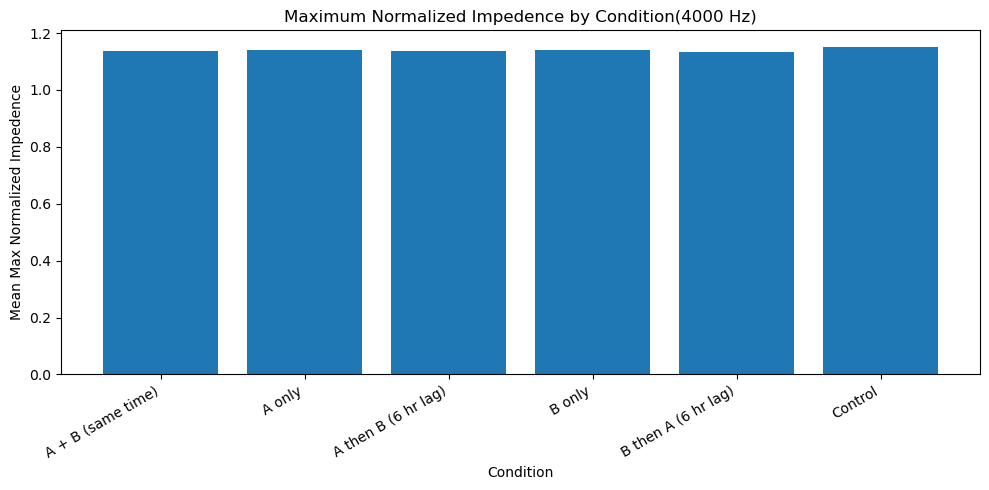

In [29]:
plt.figure(figsize = (10, 5))
plt.bar(summary_4000["Condition"], summary_4000["Mean_Max_Impedance"])
plt.xlabel("Condition")
plt.ylabel("Mean Max Normalized Impedence")
plt.title("Maximum Normalized Impedence by Condition(4000 Hz)")
plt.xticks(rotation = 30, ha = "right")
plt.tight_layout()
plt.show()

## 29. Plot Maximum Normalized Impedence at 16000 Hz

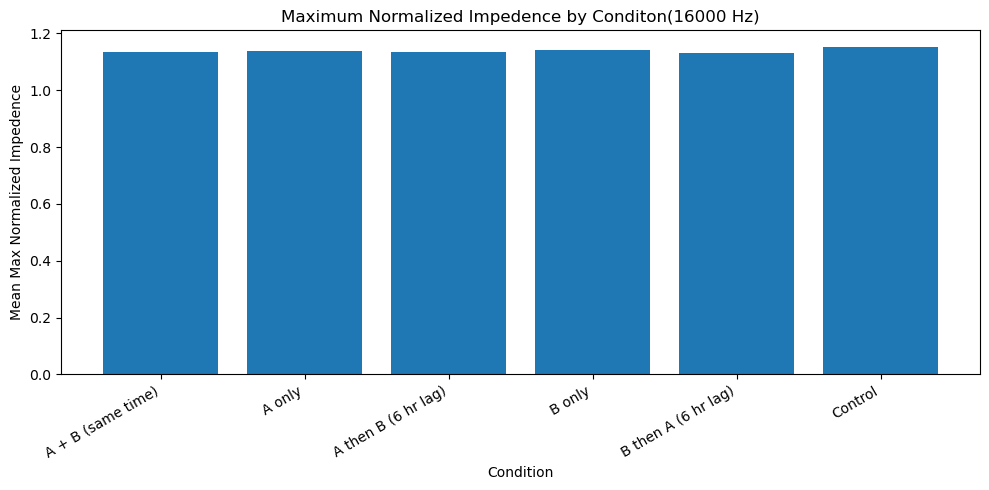

In [30]:
plt.figure(figsize = (10, 5))
plt.bar(summary_16000["Condition"], summary_16000["Mean_Max_Impedance"])
plt.xlabel("Condition")
plt.ylabel("Mean Max Normalized Impedence")
plt.title("Maximum Normalized Impedence by Conditon(16000 Hz)")
plt.xticks(rotation = 30, ha = "right")
plt.tight_layout()
plt.show()

## 30. Combine  Frequency-Level Summaries
This makes it easier to compare condition behavior across 500 Hz, 4000 Hz, and 16000 Hz. 

In [31]:
summary_500 = condition_summary.copy()
summary_500["Frequency_Hz"] = 500

summary_4000 = summary_4000.copy()
summary_4000["Frequency_Hz"] = 4000

summary_16000 = summary_16000.copy()
summary_16000["Frequency_Hz"] = 1600

all_frequency_summaries = pd.concat(
    [summary_500, summary_4000, summary_16000],
    ignore_index = True
)

all_frequency_summaries 

,Condition,Mean_Max_Impedance,SD_Max_Impedance,Mean_Time_of_Max,SD_Time_of_Max,Mean_Final_Impedance,SD_Final_Impedance,Mean_Slope,SD_Slope,Frequency_Hz
0,A + B (same time),1.139002,0.008053,4253.333333,50.083264,1.128749,0.003117,0.000030,7.214205e-07,500
1,A only,1.147437,0.002733,4290.000000,17.320508,1.136222,0.008291,0.000032,1.919230e-06,500
2,A then B (6 hr lag),1.125745,0.006603,4165.000000,21.794495,1.117496,0.009278,0.000027,2.147777e-06,500
3,B only,1.140840,0.007452,4250.000000,76.974022,1.124141,0.008685,0.000029,2.010385e-06,500
4,B then A (6 hr lag),1.127131,0.006490,4253.333333,98.149546,1.114934,0.004570,0.000027,1.057958e-06,500
5,Control,1.153978,0.000445,4261.666667,79.425017,1.138463,0.011512,0.000032,2.664749e-06,500
6,A + B (same time),1.136032,0.002672,4158.333333,50.083264,1.117673,0.003428,0.000027,7.934690e-07,4000
7,A only,1.139640,0.003414,4208.333333,80.983537,1.125781,0.005611,0.000029,1.298832e-06,4000
8,A then B (6 hr lag),1.136011,0.004126,4260.000000,30.413813,1.129465,0.010059,0.000030,2.328570e-06,4000
9,B only,1.140456,0.006522,4290.000000,36.055513,1.136654,0.008823,0.000032,2.042445e-06,4000


## 31. Compare Mean Maximum Impedence Across Frequencies 

In [32]:
pivot_max = all_frequency_summaries.pivot(
    index = "Condition",
    columns = "Frequency_Hz",
    values = "Mean_Max_Impedance"
)

pivot_max

Frequency_Hz,500,1600,4000
Condition,,,
A + B (same time),1.139002,1.134170,1.136032
A only,1.147437,1.140061,1.139640
A then B (6 hr lag),1.125745,1.133882,1.136011
B only,1.140840,1.142923,1.140456
B then A (6 hr lag),1.127131,1.130702,1.134243
Control,1.153978,1.153428,1.151932


## 33. Multifrequency Interpretation
This section compares whether the same condition-level trends remain consistent across 500 Hz, 4000 Hz, and 16000 Hz.

The main question is whether the lagged combination conditions continue to show reduced ECIS responses relative to control and single-drug conditions across multiple frequencies. If the same ranking appears at all three frequencies, that would strengthen the conclusion that the observed pattern is robust rather than frequency-specific.

## 34. Begin Physics-Based ECIS Analysis
This section starts the physics-based ECIS stage. A physics based simulator is usied to generate multifrequency ECIS data with latent biophysical parameters Rb, alpha, and cm. 
Then an inverser-fitting rountine is used to estimate the sumulated impendance signal.

In [33]:
import numpy as np 
import pandas as pd
import matplotlib.pyplot as plt

## 35. Define the Physics-Based ECIS Functions
The ECIS forward model and inverse-fitting routine are used to connect multifrequency impedance measurements to interpretable parameters Rb, alpha, and Cm.

In [70]:
from scipy.optimize import least_squares


def ecis_forward_impedance(omega, Rb, alpha, Cm, Rs=50.0):
    Y = (1.0 / Rb) + (np.sqrt(1j * omega) / alpha) + (1j * omega * Cm)
    return 1.0 / Y + Rs


def _step_exp_rise(t, t0, tau):
    x = np.maximum(0.0, t - t0)
    return 1.0 - np.exp(-x / tau)


def simulate_latent_theta(
    time_hr,
    dose_A=0,
    dose_B=0,
    lag_hr=0,
    order="A_then_B",
    Rb0=2.0,
    alpha0=8.0,
    Cm0=2e-6,
    k_Rb_A=0.20,
    k_Rb_B=0.15,
    k_alpha_A=0.20,
    k_alpha_B=0.10,
    k_Cm_A=0.10,
    k_Cm_B=0.20,
    tau_Rb=6.0,
    tau_alpha=4.0,
    tau_Cm=10.0,
    seq_coupling=0.15,
    random_state=None
):
    rng = np.random.default_rng(random_state)

    tA = 0.0
    tB = lag_hr if order == "A_then_B" else 0.0
    if order == "B_then_A":
        tA = lag_hr

    A_Rb = _step_exp_rise(time_hr, tA, tau_Rb)
    B_Rb = _step_exp_rise(time_hr, tB, tau_Rb)
    A_alpha = _step_exp_rise(time_hr, tA, tau_alpha)
    B_alpha = _step_exp_rise(time_hr, tB, tau_alpha)
    A_Cm = _step_exp_rise(time_hr, tA, tau_Cm)
    B_Cm = _step_exp_rise(time_hr, tB, tau_Cm)

    both = A_Rb * B_Rb
    seqA = 1.0 + seq_coupling * both if order == "B_then_A" else 1.0
    seqB = 1.0 + seq_coupling * both if order == "A_then_B" else 1.0

    Rb = Rb0 * (1 - k_Rb_A*dose_A*A_Rb*seqA - k_Rb_B*dose_B*B_Rb*seqB)
    alpha = alpha0 * (1 + k_alpha_A*dose_A*A_alpha*seqA + k_alpha_B*dose_B*B_alpha*seqB)
    Cm = Cm0 * (1 - k_Cm_A*dose_A*A_Cm*seqA - k_Cm_B*dose_B*B_Cm*seqB)

    Rb = np.clip(Rb + rng.normal(0, 0.02, len(Rb)), 0.05, None)
    alpha = np.clip(alpha + rng.normal(0, 0.02, len(alpha)), 0.05, None)
    Cm = np.clip(Cm + rng.normal(0, 5e-8, len(Cm)), 1e-9, None)

    return pd.DataFrame({"time_hr": time_hr, "Rb": Rb, "alpha": alpha, "Cm": Cm})


def simulate_ecis_physics_run(
    run_id,
    well_id,
    frequencies=(500, 4000, 16000),
    duration_hr=72,
    dt_min=5,
    dose_A=0,
    dose_B=0,
    lag_hr=0,
    order="A_then_B",
    Rs=50.0,
    noise_sd=2.0,
    random_state=None
):
    rng = np.random.default_rng(random_state)

    time_min = np.arange(0, duration_hr * 60 + dt_min, dt_min)
    time_hr = time_min / 60

    theta = simulate_latent_theta(
        time_hr=time_hr,
        dose_A=dose_A,
        dose_B=dose_B,
        lag_hr=lag_hr,
        order=order,
        random_state=random_state
    )

    rows = []

    for f in frequencies:
        omega = 2 * np.pi * f
        Z = ecis_forward_impedance(
            omega,
            theta["Rb"].values,
            theta["alpha"].values,
            theta["Cm"].values,
            Rs
        )

        Z = Z + rng.normal(0, noise_sd, len(Z)) + 1j * rng.normal(0, noise_sd, len(Z))

        for t, z, rb, a, cm in zip(time_min, Z, theta["Rb"], theta["alpha"], theta["Cm"]):
            rows.append({
                "run_id": run_id,
                "well_id": well_id,
                "time_min": float(t),
                "frequency_hz": float(f),
                "Zreal": float(np.real(z)),
                "Zimag": float(np.imag(z)),
                "Zmag": float(np.abs(z)),
                "Zphase": float(np.angle(z)),
                "Rb": float(rb),
                "alpha": float(a),
                "Cm": float(cm)
            })

    return pd.DataFrame(rows)


def ecis_forward(omega, Rb, alpha, Cm, Rs=50.0):
    Y = (1 / Rb) + (np.sqrt(1j * omega) / alpha) + (1j * omega * Cm)
    return 1 / Y + Rs


def fit_theta_single_time(freqs, Zobs):
    def residuals(x):
        Rb, alpha, Cm = x

        Zfit = np.array([
            ecis_forward_impedance(2 * np.pi * f, Rb, alpha, Cm)
            for f in freqs
        ])

        return np.concatenate([
            Zfit.real - Zobs.real,
            Zfit.imag - Zobs.imag
        ])

    out = least_squares(
        residuals,
        x0=[1.5, 10.0, 1e-6],
        bounds=([0.001, 1.0, 1e-10], [3.0, 50.0, 5e-6])
    )

    return {
        "Rb": out.x[0],
        "alpha": out.x[1],
        "Cm": out.x[2],
        "cost": out.cost,
        "success": out.success
    }

## 36. Simulate One Physics-Based Pilot Well
Start with one example condition so the fitting workflow can be tested before scaling to all wells.

In [71]:
df_phys = simulate_ecis_physics_run(
     run_id="pilot_phys_001",
    well_id="C5_R1",
    dose_A=10,
    dose_B=10,
    lag_hr=6,
    order="A_then_B",
    noise_sd = 0,
    random_state=101
)
df_phys.head()

,run_id,well_id,time_min,frequency_hz,Zreal,Zimag,Zmag,Zphase,Rb,alpha,Cm
0,pilot_phys_001,C5_R1,0.0,500.0,50.099874,-0.090808,50.099956,-0.001813,1.984197,7.962800,0.000002
1,pilot_phys_001,C5_R1,5.0,500.0,50.104825,-0.094489,50.104914,-0.001886,1.904136,8.364891,0.000002
2,pilot_phys_001,C5_R1,10.0,500.0,50.107816,-0.096902,50.107910,-0.001934,1.902484,8.606609,0.000002
3,pilot_phys_001,C5_R1,15.0,500.0,50.111935,-0.099914,50.112034,-0.001994,1.851644,8.942313,0.000002
4,pilot_phys_001,C5_R1,20.0,500.0,50.116194,-0.102804,50.116300,-0.002051,1.777644,9.293046,0.000002


## 37. Inspect the Simulated Physics-Based ECIS Data
This dataset now includes complex impedance values and the true latent parameters used to generate the signal.

In [72]:
print(df_phys.columns)
print(df_phys["frequency_hz"].unique())
print(df_phys["time_min"].min(), df_phys["time_min"].max())

Index(['run_id', 'well_id', 'time_min', 'frequency_hz', 'Zreal', 'Zimag',
       'Zmag', 'Zphase', 'Rb', 'alpha', 'Cm'],
      dtype='object')
[  500.  4000. 16000.]
0.0 4320.0


## 38. Fit Rb, Alpha, and Cm at One Time Point
Use all available frequencies at one time point to estimate the latent ECIS parameters.


In [73]:
ttime_point = 1440  # 24 hours

df_t = df_phys[df_phys["time_min"] == time_point].sort_values("frequency_hz")

freqs = df_t["frequency_hz"].values
Zobs = df_t["Zreal"].values + 1j * df_t["Zimag"].values

theta_hat = fit_theta_single_time(freqs, Zobs)
theta_hat

{'Rb': np.float64(0.050000054617774514),
 'alpha': np.float64(32.98594573095504),
 'Cm': np.float64(1.8673137639187395e-10),
 'cost': np.float64(2.1220424240424984e-15),
 'success': True}

## 39. Compare Estimated and True Parameters at the Selected Time Point
This checks whether the inverse-fitting routine is recovering the latent parameters reasonably well.

In [74]:
true_theta = df_t[["Rb", "alpha", "Cm"]].iloc[0].to_dict()

comparison_one_time = pd.DataFrame({
    "Parameter": ["Rb", "alpha", "Cm"],
    "True": [true_theta["Rb"], true_theta["alpha"], true_theta["Cm"]],
    "Estimated": [theta_hat["Rb"], theta_hat["alpha"], theta_hat["Cm"]]
})

comparison_one_time

,Parameter,True,Estimated
0,Rb,5.000000e-02,5.000005e-02
1,alpha,3.298620e+01,3.298595e+01
2,Cm,1.000000e-09,1.867314e-10


## 39.1 Check Model Fit at One Time Point
check if the model's fitted impendence matches the observed simulated impendence 

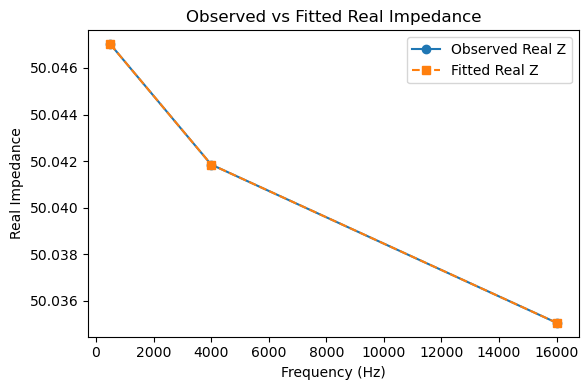

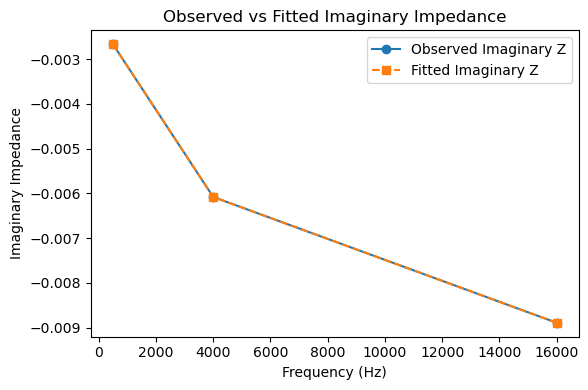

In [75]:
Zfit = np.array([
    ecis_forward_impedance(
        2 * np.pi * f,
        theta_hat["Rb"],
        theta_hat["alpha"],
        theta_hat["Cm"]
    )
    for f in freqs
])

plt.figure(figsize=(6, 4))
plt.plot(freqs, Zobs.real, "o-", label="Observed Real Z")
plt.plot(freqs, Zfit.real, "s--", label="Fitted Real Z")
plt.xlabel("Frequency (Hz)")
plt.ylabel("Real Impedance")
plt.title("Observed vs Fitted Real Impedance")
plt.legend()
plt.tight_layout()
plt.show()

plt.figure(figsize=(6, 4))
plt.plot(freqs, Zobs.imag, "o-", label="Observed Imaginary Z")
plt.plot(freqs, Zfit.imag, "s--", label="Fitted Imaginary Z")
plt.xlabel("Frequency (Hz)")
plt.ylabel("Imaginary Impedance")
plt.title("Observed vs Fitted Imaginary Impedance")
plt.legend()
plt.tight_layout()
plt.show()

## 40. Fit Latent Parameters Across All Time Points
Estimate Rb, alpha, and Cm at every recorded time point using the multifrequency impedance measurements.

In [76]:
estimated_rows = []

for t in sorted(df_phys["time_min"].unique()):
    df_t = df_phys[df_phys["time_min"] == t].sort_values("frequency_hz")

    freqs = df_t["frequency_hz"].values
    Zobs = df_t["Zreal"].values + 1j * df_t["Zimag"].values

    theta_hat = fit_theta_single_time(freqs, Zobs)

    estimated_rows.append({
        "time_min": t,
        "Rb_hat": theta_hat["Rb"],
        "alpha_hat": theta_hat["alpha"],
        "Cm_hat": theta_hat["Cm"],
        "cost": theta_hat["cost"],
        "success": theta_hat["success"]
    })

estimated_df = pd.DataFrame(estimated_rows)
estimated_df.head()

,time_min,Rb_hat,alpha_hat,Cm_hat,cost,success
0,0.0,1.984179,7.962806,0.000002,1.910529e-15,True
1,5.0,1.904135,8.364892,0.000002,8.014153e-18,True
2,10.0,1.902459,8.606621,0.000002,5.814610e-15,True
3,15.0,1.851643,8.942313,0.000002,1.496542e-17,True
4,20.0,1.777635,9.293050,0.000002,8.447446e-16,True


## 41. Build the True Latent Trajectory Table
Extract the true latent values once per time point for comparison with the estimated trajectories.

In [77]:
true_df = (
    df_phys[["time_min", "Rb", "alpha", "Cm"]]
    .drop_duplicates(subset=["time_min"])
    .sort_values("time_min")
    .reset_index(drop=True)
)

true_df.head()

,time_min,Rb,alpha,Cm
0,0.0,1.984197,7.962800,0.000002
1,5.0,1.904136,8.364891,0.000002
2,10.0,1.902484,8.606609,0.000002
3,15.0,1.851644,8.942313,0.000002
4,20.0,1.777644,9.293046,0.000002


## 42. Merge True and Estimated Parameters
This creates one table for direct trajectory comparison.

In [78]:
theta_compare = true_df.merge(estimated_df, on="time_min")
theta_compare.head()

,time_min,Rb,alpha,Cm,Rb_hat,alpha_hat,Cm_hat,cost,success
0,0.0,1.984197,7.962800,0.000002,1.984179,7.962806,0.000002,1.910529e-15,True
1,5.0,1.904136,8.364891,0.000002,1.904135,8.364892,0.000002,8.014153e-18,True
2,10.0,1.902484,8.606609,0.000002,1.902459,8.606621,0.000002,5.814610e-15,True
3,15.0,1.851644,8.942313,0.000002,1.851643,8.942313,0.000002,1.496542e-17,True
4,20.0,1.777644,9.293046,0.000002,1.777635,9.293050,0.000002,8.447446e-16,True


## 43. Plot True vs Estimated Rb

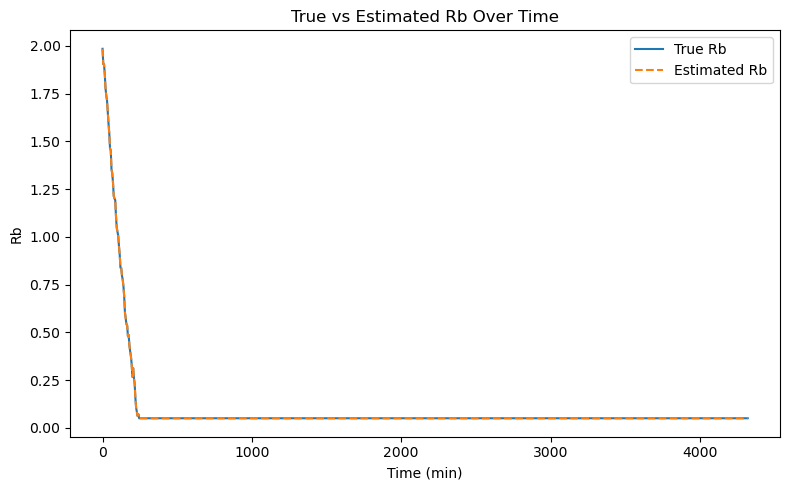

In [79]:
plt.figure(figsize=(8, 5))
plt.plot(theta_compare["time_min"], theta_compare["Rb"], label="True Rb")
plt.plot(theta_compare["time_min"], theta_compare["Rb_hat"], linestyle="--", label="Estimated Rb")
plt.xlabel("Time (min)")
plt.ylabel("Rb")
plt.title("True vs Estimated Rb Over Time")
plt.legend()
plt.tight_layout()
plt.show()

## 44. Plot True vs Estimated Alpha

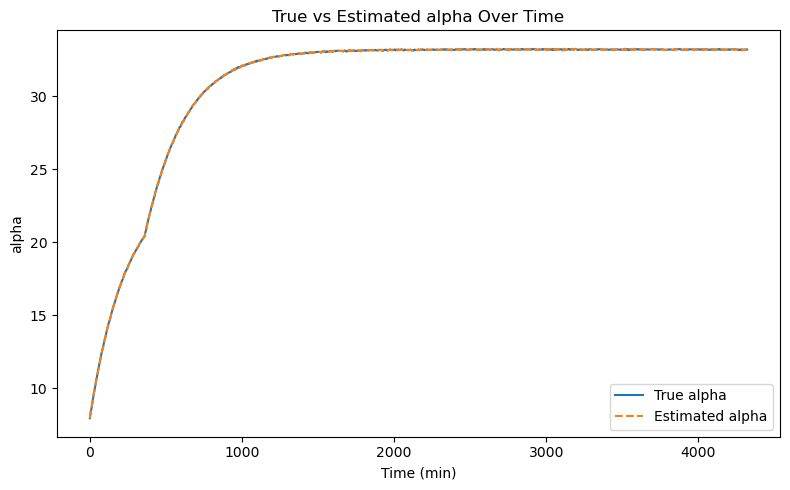

In [80]:
plt.figure(figsize=(8, 5))
plt.plot(theta_compare["time_min"], theta_compare["alpha"], label="True alpha")
plt.plot(theta_compare["time_min"], theta_compare["alpha_hat"], linestyle="--", label="Estimated alpha")
plt.xlabel("Time (min)")
plt.ylabel("alpha")
plt.title("True vs Estimated alpha Over Time")
plt.legend()
plt.tight_layout()
plt.show()

## 45. Plot True vs Estimated Cm

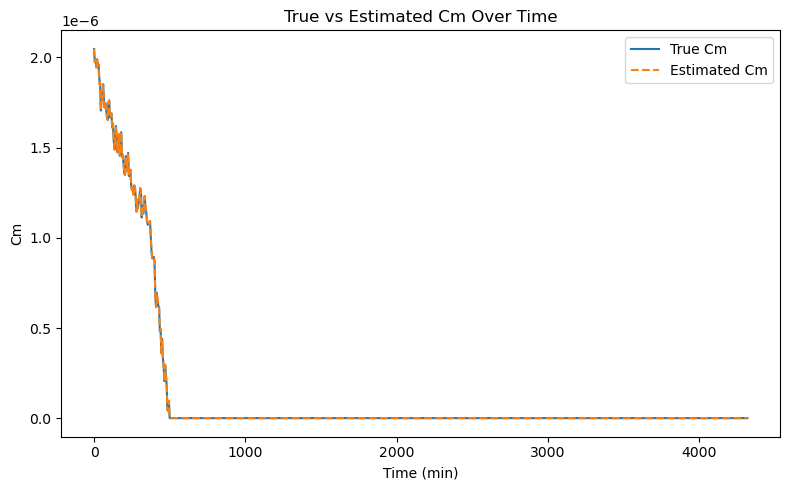

In [81]:
plt.figure(figsize=(8, 5))
plt.plot(theta_compare["time_min"], theta_compare["Cm"], label="True Cm")
plt.plot(theta_compare["time_min"], theta_compare["Cm_hat"], linestyle="--", label="Estimated Cm")
plt.xlabel("Time (min)")
plt.ylabel("Cm")
plt.title("True vs Estimated Cm Over Time")
plt.legend()
plt.tight_layout()
plt.show()

## 46. Quantify Estimation Error
Compute simple error metrics to summarize how well the inverse-fitting step recovers the latent trajectories.

In [94]:
error_summary = pd.DataFrame({
    "Parameter": ["Rb", "alpha", "Cm"],
    "MAE": [
        np.mean(np.abs(theta_compare["Rb"] - theta_compare["Rb_hat"])),
        np.mean(np.abs(theta_compare["alpha"] - theta_compare["alpha_hat"])),
        np.mean(np.abs(theta_compare["Cm"] - theta_compare["Cm_hat"]))
    ],
    "RMSE": [
        np.sqrt(np.mean((theta_compare["Rb"] - theta_compare["Rb_hat"]) ** 2)),
        np.sqrt(np.mean((theta_compare["alpha"] - theta_compare["alpha_hat"]) ** 2)),
        np.sqrt(np.mean((theta_compare["Cm"] - theta_compare["Cm_hat"]) ** 2))
    ],
    "All_Successful": [
        theta_compare["success"].all(),
        theta_compare["success"].all(),
        theta_compare["success"].all()
    ]
})

error_summary

,Parameter,MAE,RMSE,All_Successful
0,Rb,9.503086e-07,1.208179e-05,True
1,alpha,2.246846e-04,2.379447e-04,True
2,Cm,8.412083e-10,1.380255e-09,True


## 47. Interpretation

This section tested the first physics-based ECIS workflow using simulated multifrequency impedance data.

A physics-based ECIS signal was successfully simulated using latent trajectories for Rb, alpha, and Cm. The inverse-fitting routine was then applied across the available frequencies to estimate these same parameters at each time point.

After adjusting the optimizer bounds and using a clean simulated dataset with no added noise, the inverse-fitting routine was able to recover the latent parameter trajectories closely. The true and estimated curves for Rb, alpha, and Cm showed strong agreement, and the mean absolute error values were small for all three parameters.

These results suggest that the physics-based fitting workflow can recover known ECIS parameters under simplified simulated conditions. This is an important validation step before applying the method to more difficult cases, such as noisy simulations or real experimental ECIS data.

The next step is to gradually increase the difficulty of the test by adding small amounts of noise, checking whether the model still recovers the parameters accurately, and then applying the method to the pilot ECIS dataset.

## 48. Next Step: Test Physics-Based Fitting With Noise

In [95]:
df_phys_noise = simulate_ecis_physics_run(
    run_id="pilot_phys_noise_001",
    well_id="C5_R1",
    dose_A=10,
    dose_B=10,
    lag_hr=6,
    order="A_then_B",
    noise_sd=0.05,
    random_state=101
)

df_phys_noise.head()

,run_id,well_id,time_min,frequency_hz,Zreal,Zimag,Zmag,Zphase,Rb,alpha,Cm
0,pilot_phys_noise_001,C5_R1,0.0,500.0,50.060366,-0.183808,50.060704,-0.003672,1.984197,7.962800,0.000002
1,pilot_phys_noise_001,C5_R1,5.0,500.0,50.003094,-0.006974,50.003095,-0.000139,1.904136,8.364891,0.000002
2,pilot_phys_noise_001,C5_R1,10.0,500.0,50.137981,-0.212800,50.138433,-0.004244,1.902484,8.606609,0.000002
3,pilot_phys_noise_001,C5_R1,15.0,500.0,50.149150,-0.167611,50.149430,-0.003342,1.851644,8.942313,0.000002
4,pilot_phys_noise_001,C5_R1,20.0,500.0,50.100710,-0.068412,50.100757,-0.001365,1.777644,9.293046,0.000002


## 49. Fit Noisy Physics-Based Data Across All Time Points

In [96]:
estimated_noise_rows = []

for t in sorted(df_phys_noise["time_min"].unique()):
    df_t = df_phys_noise[df_phys_noise["time_min"] == t].sort_values("frequency_hz")

    freqs = df_t["frequency_hz"].values
    Zobs = df_t["Zreal"].values + 1j * df_t["Zimag"].values

    theta_hat = fit_theta_single_time(freqs, Zobs)

    estimated_noise_rows.append({
        "time_min": t,
        "Rb_hat": theta_hat["Rb"],
        "alpha_hat": theta_hat["alpha"],
        "Cm_hat": theta_hat["Cm"],
        "cost": theta_hat["cost"],
        "success": theta_hat["success"]
    })

estimated_noise_df = pd.DataFrame(estimated_noise_rows)
estimated_noise_df.head()

,time_min,Rb_hat,alpha_hat,Cm_hat,cost,success
0,0.0,3.000000,8.345735,0.000005,0.012469,True
1,5.0,0.014272,4.182196,0.000005,0.003942,True
2,10.0,3.000000,14.107581,0.000005,0.003102,True
3,15.0,3.000000,12.284951,0.000005,0.001272,True
4,20.0,0.568651,7.147569,0.000005,0.014579,True


## 50. Build True Table for Noisy Simulation

In [97]:
true_noise_df = (
    df_phys_noise[["time_min", "Rb", "alpha", "Cm"]]
    .drop_duplicates(subset=["time_min"])
    .sort_values("time_min")
    .reset_index(drop=True)
)

true_noise_df.head()

,time_min,Rb,alpha,Cm
0,0.0,1.984197,7.962800,0.000002
1,5.0,1.904136,8.364891,0.000002
2,10.0,1.902484,8.606609,0.000002
3,15.0,1.851644,8.942313,0.000002
4,20.0,1.777644,9.293046,0.000002


## 51. Merge True and Estimated Parameters for Noisy Simulation

In [98]:
theta_noise_compare = true_noise_df.merge(
    estimated_noise_df,
    on="time_min"
)

theta_noise_compare.head()

,time_min,Rb,alpha,Cm,Rb_hat,alpha_hat,Cm_hat,cost,success
0,0.0,1.984197,7.962800,0.000002,3.000000,8.345735,0.000005,0.012469,True
1,5.0,1.904136,8.364891,0.000002,0.014272,4.182196,0.000005,0.003942,True
2,10.0,1.902484,8.606609,0.000002,3.000000,14.107581,0.000005,0.003102,True
3,15.0,1.851644,8.942313,0.000002,3.000000,12.284951,0.000005,0.001272,True
4,20.0,1.777644,9.293046,0.000002,0.568651,7.147569,0.000005,0.014579,True


## 52. Plot Noisy True vs Estimated Rb

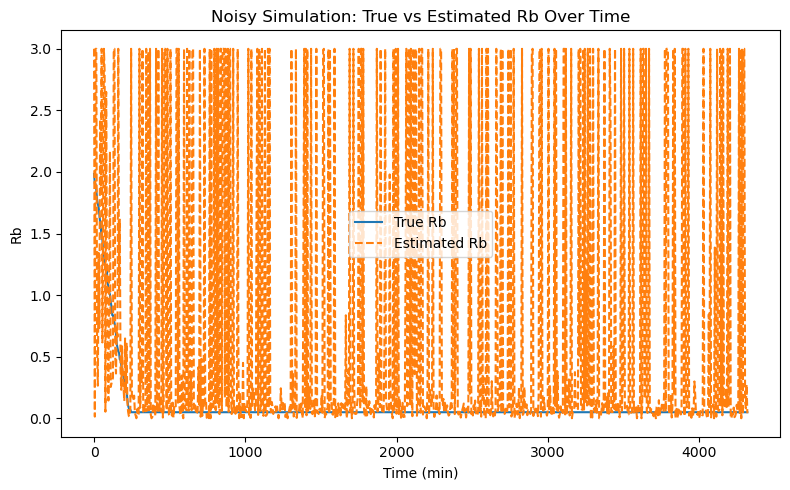

In [99]:
plt.figure(figsize=(8, 5))
plt.plot(theta_noise_compare["time_min"], theta_noise_compare["Rb"], label="True Rb")
plt.plot(theta_noise_compare["time_min"], theta_noise_compare["Rb_hat"], linestyle="--", label="Estimated Rb")

plt.xlabel("Time (min)")
plt.ylabel("Rb")
plt.title("Noisy Simulation: True vs Estimated Rb Over Time")
plt.legend()
plt.tight_layout()
plt.show()

## 53. Plot Noisy True vs Estimated Alpha

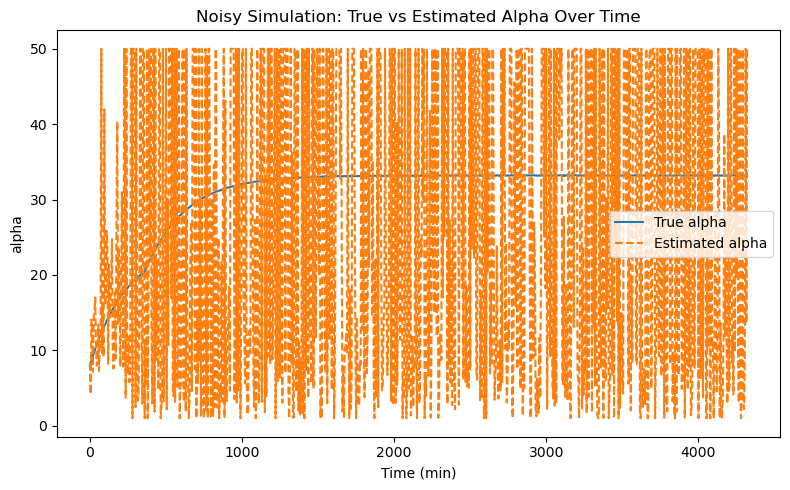

In [100]:
plt.figure(figsize=(8, 5))
plt.plot(theta_noise_compare["time_min"], theta_noise_compare["alpha"], label="True alpha")
plt.plot(theta_noise_compare["time_min"], theta_noise_compare["alpha_hat"], linestyle="--", label="Estimated alpha")

plt.xlabel("Time (min)")
plt.ylabel("alpha")
plt.title("Noisy Simulation: True vs Estimated Alpha Over Time")
plt.legend()
plt.tight_layout()
plt.show()

## 54. Plot Noisy True vs Estimated Cm

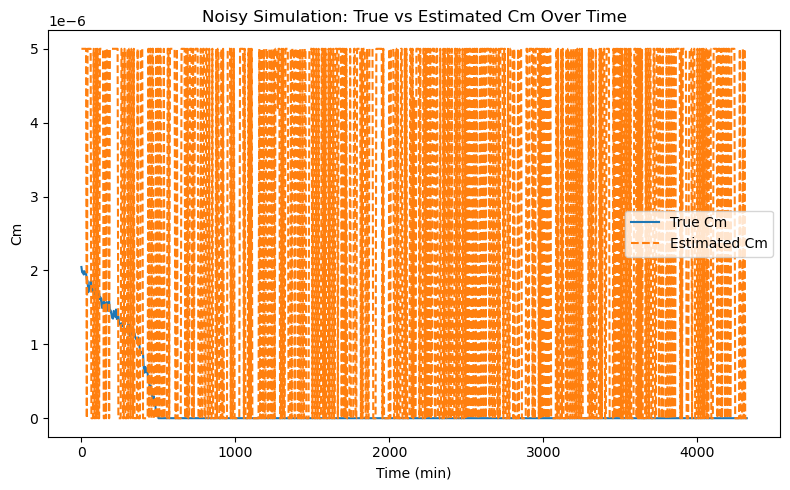

In [101]:
plt.figure(figsize=(8, 5))
plt.plot(theta_noise_compare["time_min"], theta_noise_compare["Cm"], label="True Cm")
plt.plot(theta_noise_compare["time_min"], theta_noise_compare["Cm_hat"], linestyle="--", label="Estimated Cm")

plt.xlabel("Time (min)")
plt.ylabel("Cm")
plt.title("Noisy Simulation: True vs Estimated Cm Over Time")
plt.legend()
plt.tight_layout()
plt.show()

## 55. Quantify Estimation Error for Noisy Simulation

In [102]:
noise_error_summary = pd.DataFrame({
    "Parameter": ["Rb", "alpha", "Cm"],
    "MAE": [
        np.mean(np.abs(theta_noise_compare["Rb"] - theta_noise_compare["Rb_hat"])),
        np.mean(np.abs(theta_noise_compare["alpha"] - theta_noise_compare["alpha_hat"])),
        np.mean(np.abs(theta_noise_compare["Cm"] - theta_noise_compare["Cm_hat"]))
    ],
    "RMSE": [
        np.sqrt(np.mean((theta_noise_compare["Rb"] - theta_noise_compare["Rb_hat"]) ** 2)),
        np.sqrt(np.mean((theta_noise_compare["alpha"] - theta_noise_compare["alpha_hat"]) ** 2)),
        np.sqrt(np.mean((theta_noise_compare["Cm"] - theta_noise_compare["Cm_hat"]) ** 2))
    ],
    "All_Successful": [
        theta_noise_compare["success"].all(),
        theta_noise_compare["success"].all(),
        theta_noise_compare["success"].all()
    ]
})

noise_error_summary

,Parameter,MAE,RMSE,All_Successful
0,Rb,0.640833,1.299296,True
1,alpha,19.791978,21.433254,True
2,Cm,0.000002,0.000003,True


## 56. Compare Clean vs Noisy Estimation Error

In [103]:
clean_error_summary = error_summary.copy()
clean_error_summary["Dataset"] = "Clean"

noisy_error_summary = noise_error_summary.copy()
noisy_error_summary["Dataset"] = "Noisy"

error_comparison = pd.concat(
    [clean_error_summary, noisy_error_summary],
    ignore_index=True
)

error_comparison

,Parameter,MAE,RMSE,All_Successful,Dataset
0,Rb,9.503086e-07,1.208179e-05,True,Clean
1,alpha,2.246846e-04,2.379447e-04,True,Clean
2,Cm,8.412083e-10,1.380255e-09,True,Clean
3,Rb,6.408328e-01,1.299296e+00,True,Noisy
4,alpha,1.979198e+01,2.143325e+01,True,Noisy
5,Cm,2.396937e-06,3.384306e-06,True,Noisy


## 57. Final Interpretation
The physics-based ECIS workflow was tested using both clean and noisy simulated multifrequency impedance data. First, a clean simulation with no added noise was used to confirm that the inverse-fitting routine could recover known latent parameters. After adjusting the optimizer bounds and starting values, the model successfully recovered the simulated Rb, alpha, and Cm trajectories with low estimation error.

Next, a noisy simulated dataset was created by adding noise to the impedance signal. The same inverse-fitting workflow was applied to this noisier dataset to evaluate whether the model remained stable under more realistic conditions. Comparing the clean and noisy estimation errors helped determine how sensitive the model is to measurement noise.

Overall, the clean simulation confirmed that the physics-based fitting routine can recover known ECIS parameters under simplified conditions. The noisy simulation provides an additional robustness test and shows whether the model can still estimate the latent trajectories when the impedance signal is less ideal. This completes the initial validation workflow before applying physics-based fitting to real experimental ECIS data.